<a href="https://colab.research.google.com/github/yoloaryan/Machine-Learning-Algorithms/blob/main/ml_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



# STEP 1: CREATE / LOAD DATASET


In [2]:
data = {
    'Annual_Income': [
        15, 16, 17, 19, 20,
        22, 24, 25, 28, 30,
        45, 46, 48, 50, 52,
        55, 58, 60, 62, 65
    ],

    'Spending_Score': [
        39, 81, 6, 77, 40,
        76, 35, 72, 45, 60,
        88, 90, 85, 82, 75,
        78, 65, 70, 68, 95
    ]
}

df = pd.DataFrame(data)


In [3]:
print("========== CUSTOMER DATASET ==========")
print(df)



========== CUSTOMER DATASET ==========
    Annual_Income  Spending_Score
0              15              39
1              16              81
2              17               6
3              19              77
4              20              40
5              22              76
6              24              35
7              25              72
8              28              45
9              30              60
10             45              88
11             46              90
12             48              85
13             50              82
14             52              75
15             55              78
16             58              65
17             60              70
18             62              68
19             65              95


# STEP 2: SELECT FEATURES


In [4]:
X = df[['Annual_Income', 'Spending_Score']]


# STEP 3: STANDARDIZE DATA


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# STEP 4: ELBOW METHOD


In [7]:
wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

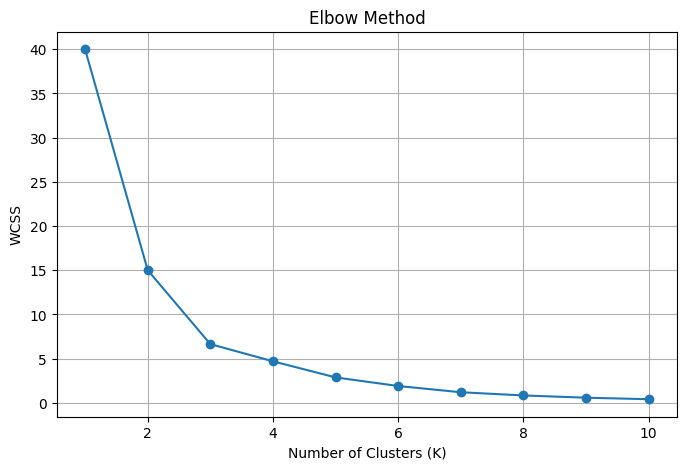

In [9]:
# Plot Elbow Curve

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.grid(True)

plt.show()


# STEP 5: APPLY K-MEANS




In [8]:
k = 3

kmeans = KMeans(
    n_clusters=k,
    init='k-means++',
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\n========== CLUSTERED DATA ==========")
print(df)




========== CLUSTERED DATA ==========
    Annual_Income  Spending_Score  Cluster
0              15              39        2
1              16              81        0
2              17               6        2
3              19              77        0
4              20              40        2
5              22              76        0
6              24              35        2
7              25              72        0
8              28              45        2
9              30              60        0
10             45              88        1
11             46              90        1
12             48              85        1
13             50              82        1
14             52              75        1
15             55              78        1
16             58              65        1
17             60              70        1
18             62              68        1
19             65              95        1


In [10]:
# STEP 6: CLUSTER COUNTS
# ==================================================

print("\n========== CUSTOMERS PER CLUSTER ==========")

print(
    df['Cluster']
    .value_counts()
    .sort_index()
)



========== CUSTOMERS PER CLUSTER ==========
Cluster
0     5
1    10
2     5
Name: count, dtype: int64


In [11]:
# STEP 7: FIND CENTROIDS
# ==================================================

centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

print("\n========== CLUSTER CENTROIDS ==========")

for i, center in enumerate(centers):

    print(
        f"Cluster {i + 1}: "
        f"Annual Income = {center[0]:.2f}, "
        f"Spending Score = {center[1]:.2f}"
    )

#


========== CLUSTER CENTROIDS ==========
Cluster 1: Annual Income = 22.40, Spending Score = 73.20
Cluster 2: Annual Income = 54.10, Spending Score = 79.60
Cluster 3: Annual Income = 20.80, Spending Score = 33.00


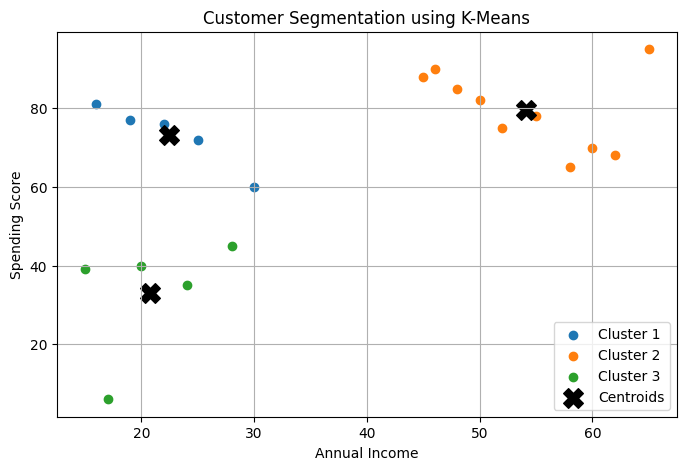

In [12]:
# STEP 8: PLOT CLUSTERS
# ==================================================

plt.figure(figsize=(8, 5))

for cluster in range(k):

    cluster_data = df[df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['Annual_Income'],
        cluster_data['Spending_Score'],
        label=f'Cluster {cluster + 1}'
    )

# Plot centroids

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation using K-Means')
plt.legend()
plt.grid(True)

